# 🔎 "Find me more like this one" — Similarity Search in the FLARE feature space

### Teaching notebook #2 — companion to `flare_tutorial.ipynb`

In the first notebook we taught a machine to *classify* light curves.
But astronomers often ask a different question:

> *"I found this weird object. Are there **others like it** in the archive?"*

That is **similarity search** — and at ZTF/LSST scale (millions of alerts per
night) you cannot answer it by eye. In this lesson we build a similarity-search
engine on top of FLARE, using its **160 physics features as an embedding**: every
object becomes a point in a 160-dimensional space, and *"similar objects"* simply
means *"nearby points"*.

**Why the FLARE features make a great embedding:** unlike a neural network's
hidden vector, every dimension *means something* (a colour, a timescale, a
smoothness). When two objects are neighbours, you can say **why**.

**The plan:**
1. Turn the archive into vectors 📐
2. Exact nearest-neighbour search: query with a TDE 🎯
3. A 2-D map of the transient sky 🗺️
4. k-NN as a classifier (and how it compares to trees) 🤝
5. Distance as a **weirdness score** — anomaly detection 👽
6. Scaling to millions: approximate search (Annoy / FAISS) ⚡

> This notebook is a compact, real-data companion to the full lecture series
> [`SimilaritySearch`](https://github.com/asasli/SimilaritySearch), which goes
> deeper: metric learning, multimodal retrieval, and active-learning loops.

In [1]:
# --- Setup ---------------------------------------------------------------
import os, sys, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from flare import FlareClassifier, BROAD_CLASSES
from flare import data as D
from flare.taxonomy import ID2BROAD_ID

DATA_DIR = os.environ.get("FLARE_DATA",
    "/work/hdd/bcrv/ffontinelenunes/data/AppleCider/photo_events")
D.DATA_DIR = __import__("pathlib").Path(DATA_DIR)

CLASS_COLOR = {"SNI": "#0072B2", "SNII": "#E69F00", "CV": "#009E73",
               "AGN": "#CC79A7", "TDE": "#D55E00"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Setup OK")

Setup OK


## 1. The archive as a cloud of points 📐

We take the test catalogue (≈2000 objects FLARE has never trained on) and compute
the 160 features for each — the same function the classifier uses. Two practical
details every real system needs:

* **Missing values** — some objects have no *i*-band, some fits fail → `NaN`.
  Trees handle `NaN` natively, but *distances* don't. We fill each missing value
  with the feature's **median**.
* **Scaling** — a feature measured in days must not drown one measured in
  magnitudes. We use a **robust scaler** (median / interquartile range), which
  ignores the wild outliers astronomical data always contains.

In [2]:
# Build the archive: features for ~2000 unseen objects (takes ~a minute)
clf = FlareClassifier.from_pretrained()          # we reuse its feature list
manifest = D.load_manifest("test")
kept, _ = D.filter_manifest_quality(manifest)
labels = np.array([BROAD_CLASSES[ID2BROAD_ID[int(l)]] for l in kept.label])

X_raw = clf.features_from_files(kept.filepath.tolist())     # (N, 160) with NaNs
print(f"archive: {X_raw.shape[0]} objects x {X_raw.shape[1]} features "
      f"| missing values: {np.isnan(X_raw.values).mean():.1%}")

E20260718 23:08:20.564857 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 23:08:20.631261 3177880 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260718 23:08:20.631313 3177880 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.
E20260718 23:08:20.631412 3177880 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260718 23:08:20.631421 3177880 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.
E20260718 23:08:20.759322 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 23:08:21.058928 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 23:08:21.165231 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 23:08:21.639457 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 23:08:21.710834 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 23:08:22.210561 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 23:08:22.480230 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 23:08:22.480684 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 23:08:22.930603 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 23:08:23.243111 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 23:08:23.360132 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 23:08:23.440194 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260718 23:08:23.531985 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 23:08:23.561043 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260718 23:08:23.680059 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


archive: 1979 objects x 160 features | missing values: 28.7%


E20260718 23:08:24.154755 3177880 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


In [3]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

imputer = SimpleImputer(strategy="median")
scaler  = RobustScaler()
X = scaler.fit_transform(imputer.fit_transform(X_raw))
X = np.clip(X, -10, 10)          # tame the few extreme outliers
print("embedded:", X.shape, "— every object is now a point in 160-D space")

embedded: (1979, 160) — every object is now a point in 160-D space


## 2. Query the archive: *"more like this TDE, please"* 🎯

The simplest search is **exact k-nearest neighbours**: compute the distance from
the query to every archive point and keep the closest *k*. For a few thousand
objects this takes milliseconds.

We use **cosine distance** (angle between vectors) — a standard choice for
embeddings, because it compares the *pattern* of features rather than their
overall magnitude.

In [4]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=6, metric="cosine").fit(X)

# query with a real TDE
q_idx = np.where(labels == "TDE")[0][0]
dist, ind = nn.kneighbors(X[q_idx:q_idx+1])
print(f"query: {kept.iloc[q_idx].obj_id} (a real TDE)\n")
print("rank  object          class  cosine distance")
for r, (i, d) in enumerate(zip(ind[0], dist[0])):
    tag = "  <-- the query itself" if i == q_idx else ""
    print(f"  {r}   {kept.iloc[i].obj_id:14s} {labels[i]:5s}  {d:.3f}{tag}")

query: ZTF21abcgnqn (a real TDE)

rank  object          class  cosine distance
  0   ZTF21abcgnqn   TDE    0.000  <-- the query itself
  1   ZTF20acbcfaa   SNII   0.223
  2   ZTF20abisrhp   SNI    0.256
  3   ZTF20aacbtgq   SNI    0.264
  4   ZTF24aazlori   TDE    0.270
  5   ZTF19abcekqa   AGN    0.272


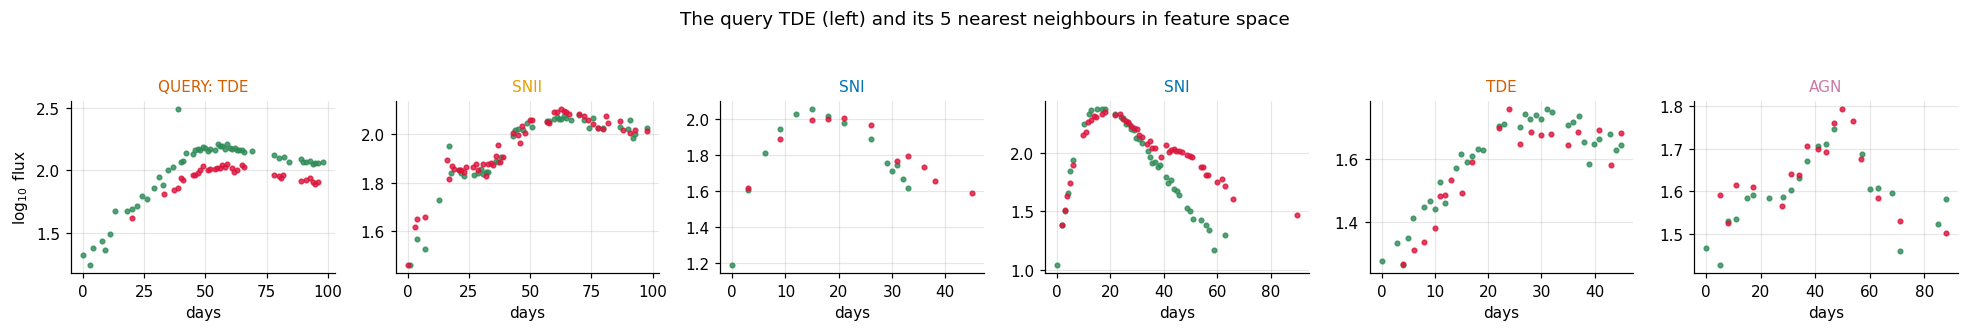

In [5]:
# Let's SEE them — the query and its 5 nearest neighbours
fig, axes = plt.subplots(1, 6, figsize=(18, 2.8))
for ax, i in zip(axes, ind[0]):
    arr = D.load_events(kept.iloc[i].filepath)
    bands = D.reconstruct_bands(arr)
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            ax.plot(bands[name].t, bands[name].logflux, "o", ms=3, color=colr, alpha=0.8)
    cls = labels[i]
    ax.set_title(("QUERY: " if i == ind[0][0] else "") + f"{cls}",
                 color=CLASS_COLOR[cls], fontsize=10)
    ax.set_xlabel("days")
axes[0].set_ylabel(r"$\log_{10}$ flux")
plt.suptitle("The query TDE (left) and its 5 nearest neighbours in feature space", y=1.06)
plt.tight_layout(); plt.show()

The neighbours *look like the query* — smooth blue declines. Some may be other
TDEs; some may be TDE-*like* AGN, which is precisely the confusion that matters
scientifically. And because the dimensions are physical, you can ask **which
features made them neighbours** (colour? fall time? smoothness?).

### ✏️ Exercise 1
Query with a **CV** instead (change `"TDE"` to `"CV"` above). Are its neighbours
also CVs? Why do repeated-outburst objects cluster so tightly?

## 3. A map of the transient sky 🗺️

160 dimensions are hard to imagine. Let's project the archive to 2-D with **PCA**
(keeping the directions of largest variance) and colour it by true class — a
"map" where similar objects sit together.

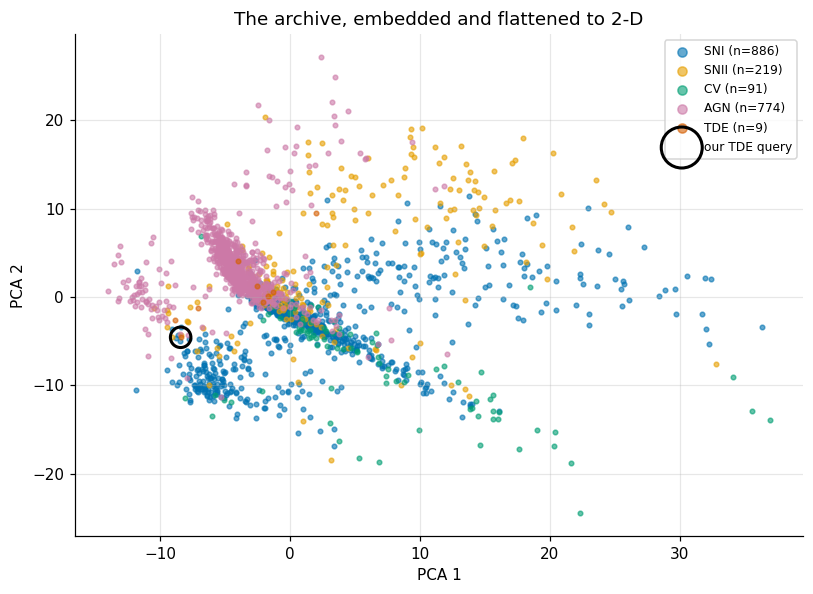

In [6]:
from sklearn.decomposition import PCA

Z = PCA(n_components=2, random_state=0).fit_transform(X)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for cls in BROAD_CLASSES:
    m = labels == cls
    ax.scatter(Z[m, 0], Z[m, 1], s=9, alpha=0.6, color=CLASS_COLOR[cls],
               label=f"{cls} (n={m.sum()})")
ax.scatter(Z[q_idx, 0], Z[q_idx, 1], s=180, facecolor="none",
           edgecolor="black", lw=2, label="our TDE query")
ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2")
ax.set_title("The archive, embedded and flattened to 2-D")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()

Classes form **islands** — the embedding organises the sky by physics without
being told the labels. (For prettier maps, try UMAP or t-SNE; PCA is the honest,
linear baseline.)

## 4. k-NN as a classifier 🤝

If my neighbours are mostly AGN, I'm probably an AGN. That's **k-NN
classification** — no training at all, just the archive and a distance. Let's
test it honestly with leave-one-out on the archive (each object votes using its
neighbours, *excluding itself*).

In [7]:
k = 15
dist_all, ind_all = NearestNeighbors(n_neighbors=k+1, metric="cosine").fit(X).kneighbors(X)
votes = labels[ind_all[:, 1:]]                       # drop self (column 0)
knn_pred = pd.DataFrame(votes).mode(axis=1)[0].values
knn_acc = (knn_pred == labels).mean()

flare_pred = np.array(BROAD_CLASSES)[clf.predict_proba(X_raw).argmax(1)]
flare_acc = (flare_pred == labels).mean()

print(f"k-NN (k={k}) accuracy on the archive : {knn_acc:.3f}")
print(f"FLARE (trees)  accuracy, same objects: {flare_acc:.3f}")
per = pd.DataFrame({"kNN": pd.Series(labels[knn_pred == labels]).value_counts()
                            / pd.Series(labels).value_counts(),
                    "FLARE": pd.Series(labels[flare_pred == labels]).value_counts()
                            / pd.Series(labels).value_counts()}).round(2)
per.loc[BROAD_CLASSES]

k-NN (k=15) accuracy on the archive : 0.856
FLARE (trees)  accuracy, same objects: 0.957


,kNN,FLARE
SNI,0.95,0.97
SNII,0.25,0.84
CV,0.60,0.91
AGN,0.97,0.98
TDE,NaN,0.33


**Lesson:** plain neighbourhood voting already gets a long way — the features do
most of the work! The boosted trees still win (they learn *which* features matter
for *which* boundary, and weight the rare classes), but k-NN needs **zero
training** and gives you retrieval for free. In production the two are
complementary: FLARE for the probabilities, the index for "show me similar ones".

### ✏️ Exercise 2
Try `k = 3` and `k = 50`. Which classes benefit from a small `k`, which from a
large one — and why? (Hint: how many TDEs exist in the whole archive?)

## 5. Distance as a weirdness score 👽

Flip the logic: an object whose nearest neighbours are **far away** is *unlike
everything in the archive* — an **anomaly**. At survey scale, this is how you
hunt for objects nobody has seen before.

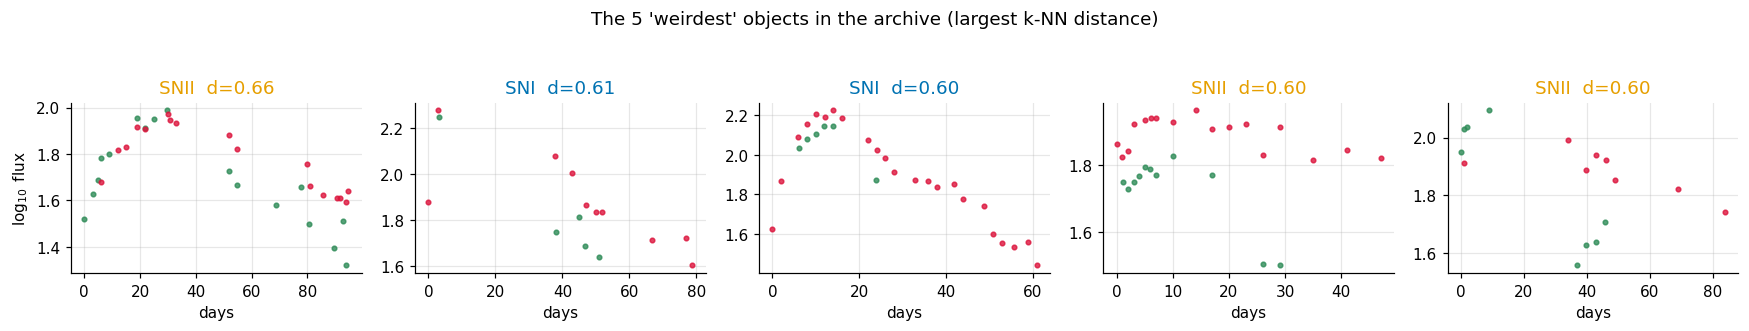

class mix of the top-40 weirdest: {'SNI': np.int64(20), 'AGN': np.int64(10), 'SNII': np.int64(9), 'TDE': np.int64(1)}


In [8]:
# weirdness = distance to the k-th nearest neighbour
weirdness = dist_all[:, -1]
order = np.argsort(weirdness)[::-1]

fig, axes = plt.subplots(1, 5, figsize=(16, 2.8))
for ax, i in zip(axes, order[:5]):
    arr = D.load_events(kept.iloc[i].filepath)
    bands = D.reconstruct_bands(arr)
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            ax.plot(bands[name].t, bands[name].logflux, "o", ms=3, color=colr, alpha=0.8)
    ax.set_title(f"{labels[i]}  d={weirdness[i]:.2f}", color=CLASS_COLOR[labels[i]])
    ax.set_xlabel("days")
axes[0].set_ylabel(r"$\log_{10}$ flux")
plt.suptitle("The 5 'weirdest' objects in the archive (largest k-NN distance)", y=1.06)
plt.tight_layout(); plt.show()

print("class mix of the top-40 weirdest:",
      dict(pd.Series(labels[order[:40]]).value_counts()))

Notice who shows up: sparse, extreme, or genuinely unusual light curves — and
rare classes are over-represented among the "weird". A human looking at 40
candidates per night is feasible; looking at 500,000 is not. **That is the point
of similarity search.**

### ✏️ Exercise 3
Plot the histogram of `weirdness` per class (`plt.hist` with one colour per
class). Which class is intrinsically the most "self-similar"?

## 6. Scaling up: approximate nearest neighbours ⚡

Exact search compares the query to *every* archive point — fine for $10^3$,
impossible for $10^8$. **Approximate NN** libraries (Annoy, FAISS, Voyager)
build clever tree/graph indexes that answer queries in ~logarithmic time,
trading a tiny bit of recall for orders-of-magnitude speed.

The cell below uses them *if installed* and skips gracefully otherwise —
the full comparison lives in the
[`SimilaritySearch`](https://github.com/asasli/SimilaritySearch) lecture series.

In [9]:
Xf = np.ascontiguousarray(X, dtype=np.float32)

t0 = time.time(); NearestNeighbors(n_neighbors=6).fit(Xf).kneighbors(Xf[:200])
print(f"exact (sklearn) : {1000*(time.time()-t0)/200:6.2f} ms / query")

try:
    import faiss
    index = faiss.IndexFlatL2(Xf.shape[1]); index.add(Xf)
    t0 = time.time(); index.search(Xf[:200], 6)
    print(f"FAISS flat      : {1000*(time.time()-t0)/200:6.2f} ms / query")
except ImportError:
    print("FAISS not installed — `pip install faiss-cpu` to try it")

try:
    from annoy import AnnoyIndex
    ann = AnnoyIndex(Xf.shape[1], "euclidean")
    for i, v in enumerate(Xf): ann.add_item(i, v)
    ann.build(20)
    t0 = time.time()
    for i in range(200): ann.get_nns_by_item(i, 6)
    print(f"Annoy (20 trees): {1000*(time.time()-t0)/200:6.2f} ms / query")
except ImportError:
    print("Annoy not installed — `pip install annoy` to try it")

exact (sklearn) :   0.66 ms / query
FAISS not installed — `pip install faiss-cpu` to try it
Annoy not installed — `pip install annoy` to try it


## 7. What you learned 🎓

1. A **feature vector is an embedding** — and physics features give you an
   *interpretable* one.
2. **k-NN retrieval** answers "find more like this" in milliseconds, and the
   neighbours can be *explained* feature by feature.
3. A 2-D **map** of the embedding shows classes clustering by physics alone.
4. **k-NN classification** is a strong zero-training baseline; boosted trees
   refine it. Classifier + index = a complete production system.
5. **Distance = weirdness**: the same index is an anomaly detector for free.
6. **Approximate NN** (Annoy/FAISS) makes all of this work at LSST scale.

### 🏆 Final challenge
Build the index from the **day-10 features** instead
(`clf.features_from_files(..., horizon_days=10)`).
Query with the same TDE. Are its early-time neighbours still TDE-like — or do
young TDEs hide among the supernovae? What does that mean for real-time
follow-up?

---
*Continue with the full lecture series —
[github.com/asasli/SimilaritySearch](https://github.com/asasli/SimilaritySearch):
metric learning (make TDEs cluster tighter), multimodal retrieval
(light curve → spectrum), and active-learning feedback loops.*